In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d


We want to find the $k$-dependent eigenvalues of matrix $\boldsymbol{A}(k)$. If, for a given temperature $\beta$, all eigenvalues for all $k$ are negative, the uniform distribution is stable and no clustering will occur.
The matrix depends on the pairwise interaction potential $W$ (rather, its Fourier transform). 

We start with the Gaussian case. 

Since we are on the torus, we may use the periodic extension of the Gaussian interaction potential, which will ease the calculation.  
The potential is given by 
$$W(r) = -\sum^{\infty}_{n=-\infty}\exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}.$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by

$$
\begin{align}
\hat{W}(k) &= \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}-ikr\right)}dr, \\
           &=- \sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr, \\
           &= -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\cos{(kr)}dr,\\
           &= -\int^{\infty}_{-\infty} \exp{\left(-\frac{r^{2}}{2\sigma^{2}}\right)}\cos{\left(\frac{2\pi z r}{L}\right)}dr, \\
           &= -\sqrt{2\pi \sigma^2}e^{-2\sigma^{2}\pi^{2}z^{2}/L^{2}} = -\sqrt{2\pi \sigma^2} e^{-\sigma^{2}k^{2}/2}.
\end{align}
$$


An alternative is to use the non-periodic Gaussian (the one actually considered in the simulation):

$$ 
\hat{W}(k)=-\int_{-\frac{L}{2}}^{\frac{L}{2}} e^{\frac{r^2}{2\sigma^2}}e^{-ikr}dr=...=-\sqrt{\frac{\pi \sigma^2}{2}}e^{-\frac{k^2\sigma^2}{2}}\left[ erf\left( \frac{\frac{L}{2}-ik\sigma^2}{\sqrt{2\sigma^2}} \right) +erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right] = -\sqrt{2\pi\sigma^2} e^{-\frac{-k^2\sigma^2}{2}}Re\left( erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right).
$$

Here, $erf$ denotes the error function. Since $\frac{\sigma}{L}$ is small, the differences between the two expressions are exponentially small.

In [73]:
# Fourier transform of the Gaussian interaction.

σ = np.sqrt(5)    # Width.
L = 10            # Boxlength.

# Wrapped / periodic Gaussian.
def W_hat(k):
    W_hat_k = -np.sqrt(2*np.pi)*σ*np.exp(-σ**2 * k**2 /2) 
    return W_hat_k

# Non-wrapped case:
#from scipy.special import erf
#def W_hat(k):
#    W_hat_k = -np.sqrt(2*np.pi)*σ * np.exp(-σ**2*k**2/2)*np.real( erf( (0.5*L + 1j*k*σ**2)/(np.sqrt(2*σ**2)) ) )
#    return W_hat_k




In [66]:
# Matrix A(k) for given values of k, beta, gamma, L. We truncate it after the first "dim" rows/columns.

def A_matrix(k,β,γ,L,dim):
    
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    
    A_k[dim-1][dim-1] = (dim-1)*-γ
    
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat(k)/L  
    
    return A_k

In [67]:
# For a given number of beta and gamma values, this function yields the spectral radius of A(k) for each of them.
# It also takes as input "dim" the number of dimensions (i.e., rows and columns) to consider and k_max the number 
# of wavenumbers to test.


def compute_spectral(beta_list, gamma_list, dim, k_max):

    N_beta = len(beta_list)
    N_gamma = len(gamma_list)
    
    spectral_radius = np.zeros((N_beta, N_gamma))  # Will store spectral radius.
    
    
    for i in range(len(beta_list)):
        
        beta = beta_list[i]
        print("Testing beta ", beta)
        
        for j in range(len(gamma_list)):
            
            gamma = gamma_list[j]
            
            # Get spectral radius for k=0.
            matrix = A_matrix(0, beta, gamma, L, dim)
            maximum = np.max( np.real( np.linalg.eigvals(matrix) ) ) 
            
            # Test all other wavenumbers.
            for z in range(1, k_max):
                
                k = 2*np.pi*z/L
                
                matrix = A_matrix(k, beta, gamma, L, dim)
                
                partial_max = np.max( np.real( np.linalg.eigvals(matrix) ) )
                
                if partial_max > maximum:
                    maximum = partial_max
                
                
                # Test negative k.
                k = -k 
                matrix = A_matrix(k, beta, gamma, L, dim)
                partial_max = np.max( np.real( np.linalg.eigvals(matrix) ) )
                
                if partial_max > maximum:
                    maximum = partial_max
            
            spectral_radius[i,j] = maximum
    
    return spectral_radius

In [68]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 100
beta_list = np.linspace(1, 10, N_beta)

N_gamma = 10
gamma_list = np.linspace(0.01, 1, N_gamma)

dim = 50    # Pick large enough such that results converge.

k_max = 50  # Pick large enough such that results converge.

spectral_radius = compute_spectral(beta_list, gamma_list, dim, k_max)


Testing beta  1.0
Testing beta  1.0909090909090908
Testing beta  1.1818181818181819
Testing beta  1.2727272727272727
Testing beta  1.3636363636363638
Testing beta  1.4545454545454546
Testing beta  1.5454545454545454
Testing beta  1.6363636363636362
Testing beta  1.7272727272727273
Testing beta  1.8181818181818183
Testing beta  1.9090909090909092
Testing beta  2.0
Testing beta  2.090909090909091
Testing beta  2.1818181818181817
Testing beta  2.2727272727272725
Testing beta  2.3636363636363638
Testing beta  2.4545454545454546
Testing beta  2.5454545454545454
Testing beta  2.6363636363636367
Testing beta  2.7272727272727275
Testing beta  2.8181818181818183
Testing beta  2.909090909090909
Testing beta  3.0
Testing beta  3.090909090909091
Testing beta  3.1818181818181817
Testing beta  3.272727272727273
Testing beta  3.3636363636363638
Testing beta  3.4545454545454546
Testing beta  3.5454545454545454
Testing beta  3.6363636363636362
Testing beta  3.7272727272727275
Testing beta  3.8181818181

In [71]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )


Linear stability analysis result for critical Beta:  9.363636363636363




Formula for critical beta $\beta_c$ for the Gaussian interaction by Martzel & Aslangul (2001):

$ \Huge \beta_c = \frac{L^d}{(2\pi)^{\frac{d}{2}}\sigma^d}$  

for dimensionality $d$ ($d=1$ in our case). 

In [72]:
# Print critical beta given by literature (Martzel & Aslangul, 2001).

print('Theoretical critcal beta in 1D ', L/(σ*np.sqrt(2*np.pi)))
print('Theoretical critcal beta in 2D ', L**2/(σ**2*2*np.pi)) 
print('Theoretical critcal beta in 3D ', L**3/(σ**3*(2*np.pi)**(3/2)))


Theoretical critcal beta in 1D  8.920620580763858
Theoretical critcal beta in 2D  79.57747154594767
Theoretical critcal beta in 3D  709.880430437931


The deviations between the literature result and our result decrease for smaller $\frac{\sigma}{L}$ as can be easily verified be re-running the script for different values of $L$ and $\sigma$. See also Sec. REF in the supplementary material.

Text(0, 0.5, 'Spectral radius')

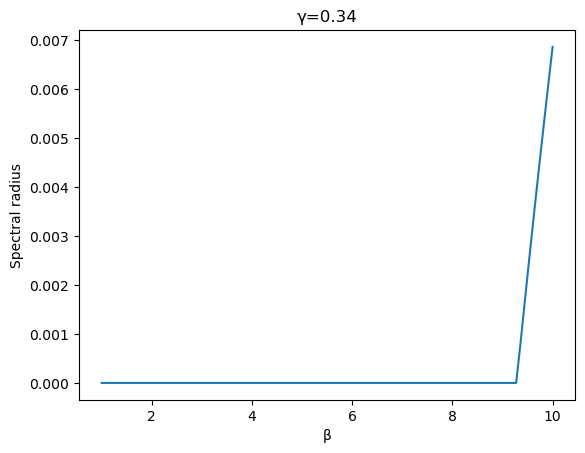

In [77]:
# Plot spectral radius against beta at fixed gamma.

plt.plot(beta_list, spectral_radius[:,gamma_idx])

plt.title('γ='+str(γ_list[gamma_idx]))
plt.xlabel('β')
plt.ylabel('Spectral radius')


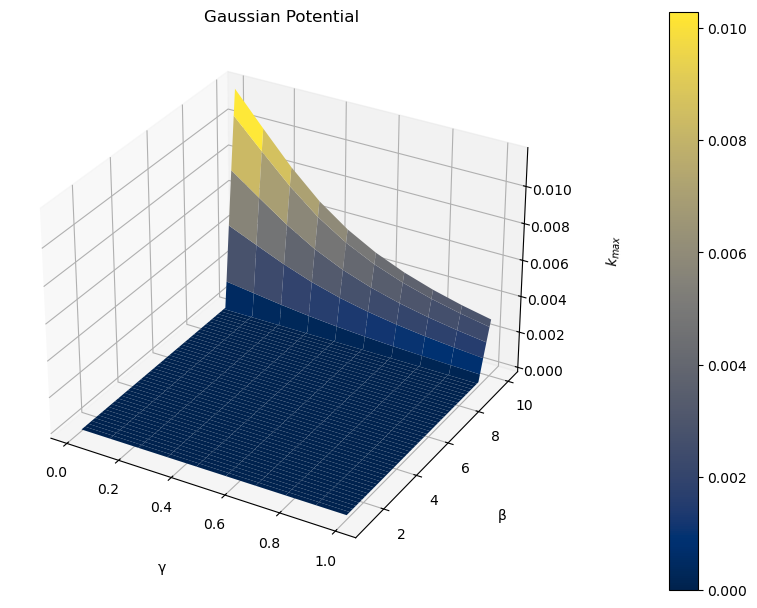

In [90]:
# Plot spectral radius vs. (gamma, beta).

fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(gamma_list, beta_list)

surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)

ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
ax.set_title('Gaussian Potential')

fig.colorbar(surf, shrink=0.5, aspect=20, pad=0.15)

plt.show()

As can be seen from this diagram, $\beta_c$ is independent of friction $\gamma$ as expected.

Text(0, 0.5, 'Theoretical Cluster Time for 1000 particles')

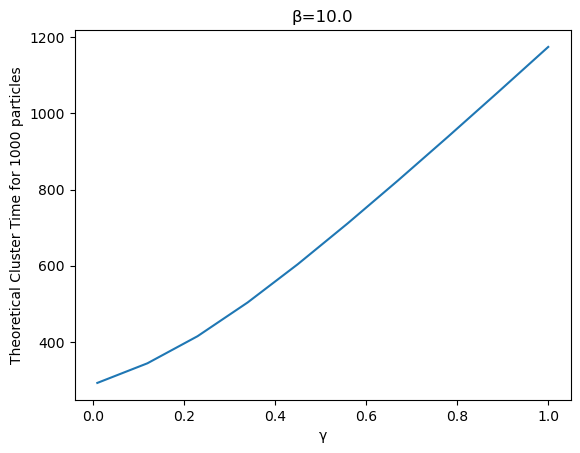

In [91]:
# Plot time to onset of clustering for fixed gamma at beta > beta_c.

plt.plot(gamma_list, np.log(1000)/(2*spectral_radius[-1,:]))
plt.title('β='+str(beta_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

We observe an overall linear regime with deviations upwards for $\gamma \to 0$ (consistent with the simulation results in the main text).

# Von Mises-Fisher

For the Von Mises-Fisher potential defined on $[-L/2,L/2]$ we have that $$W(r) = - I_{0}(\kappa)^{-2}\exp{\left\{\theta\cos(2\pi x/L)\right\}}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)-ikr\right)}dr$$
$$ = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$ = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)\right)}\cos{(\frac{2\pi z r}{L})}dr. $$

In [ ]:
from scipy.special import jv
from scipy.integrate import quad

θ = 1.
κ = 1

#@numba.jit(nopython=True)
def integrand(r,z):
    #integrate numerically
    des = -np.exp(θ*np.cos(2*np.pi*r/L))*np.cos(z*r)/jv(0, κ)**2
    return des 


def W_hat_VMF(k):
    #integrate numerically
    W_hat_k = quad(integrand,-L/2,L/2,args = (k))
    return W_hat_k[0]


def matrix_VMF(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_VMF(k)/L
    return A_k

In [ ]:
print(np.max(np.real(np.linalg.eigvals(matrix_VMF(1,1,1.,10,20)))))
print(np.max(np.real(np.linalg.eigvals(matrix_VMF(1,10,1.,10,20)))))

In [ ]:
def function_VMF():
    N_β = 30
    N_γ = 100
    β_list = np.linspace(0.001,30,N_β)
    γ_list = np.linspace(0.0,10,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    spectral_radius = np.zeros((N_β,N_γ))
    k_max = 10
    approximation_dimension = 15
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix_VMF(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix_VMF(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius

In [ ]:
# β_list,γ_list,spectral_radius = function_VMF()

# plt.plot(γ_list,np.log(1000)/2*spectral_radius[0,:])
# plt.show()
# #plt.xscale('log')

# print(spectral_radius)

In [ ]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
#plt.xscale('log')
#plt.yscale('log')
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

In [ ]:
plt.plot(β_list,spectral_radius[:,-1])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[-1]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

In [ ]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Von Mises-Fisher Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()

# Morse potential

For the Morse potential defined on $[-L/2,L/2]$ we have that $$W(r) = D_{e}(e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)})$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) =  D_e \int^{L/2}_{-L/2} (e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)})\cos{(2\pi zr/L)}dr . $$

In [1]:
from scipy.special import jv
from scipy.integrate import quad

# to do
L  = 10.
De = 1
re = 0
a  = 2

#@numba.jit(nopython=True)
def integrand_MORSE(r,z):
    #integrate numerically
    des = De*(np.exp(-2*a*(np.abs(r)-re))-2*np.exp(-a*(np.abs(r)-re)))*np.cos(z*r)
    return des 


def W_hat_MORSE(k):
    #integrate numerically
    W_hat_k = quad(integrand_MORSE,-L/2,L/2,args = (k,))
    return W_hat_k[0]


def matrix_MORSE(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_MORSE(k)/L
    return A_k



In [14]:
print(np.max(np.real(np.linalg.eigvals(matrix_MORSE(1,1,1.,L,15)))))
print(np.max(np.real(np.linalg.eigvals(matrix_MORSE(1,100,10.,L,15)))))

-0.6026848633007849
0.02261226505106414


In [26]:
def function_MORSE():
    N_β = 300    # Number of temperature points.
    N_γ = 4      # Number of friction points.
    β_list = np.linspace(1,20,N_β)
    γ_list = np.linspace(0.0,1,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    #γ_list = np.linspace(0.01,1,1)
    
    spectral_radius = np.zeros((N_β,N_γ))  # store largest real part of eigenvalues here.
    
    k_max = 50  # number of wavenumbers to test.
    
    approximation_dimension = 50  # number of matrix rows to consider.
    
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix_MORSE(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix_MORSE(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius



In [27]:
β_list,γ_list,spectral_radius = function_MORSE()

# plt.plot(γ_list,np.log(1000)/2*spectral_radius[0,:])
# plt.show()
# #plt.xscale('log')

# print(spectral_radius)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [29]:
# Print the first beta at which eigenvalues become positive (should align with theoretical prediction above):


gamma_idx = 2 # which gamma to consider (T_crit should be independent of it anyway)
beta_c = β_list[ np.argmax(spectral_radius[:,gamma_idx]>0) ]
print("Crit. Beta: ", beta_c )




Crit. Beta:  7.545150501672241


In [35]:
print(spectral_radius)


[[ 4.90274488e-13 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 [ 4.97379913e-13 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 [ 5.96855899e-13 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 ...
 [ 1.65096300e-01  1.21392311e-01  8.75166897e-02  6.58714401e-02]
 [ 1.65697745e-01  1.21816677e-01  8.78149142e-02  6.60943488e-02]
 [ 1.66296033e-01  1.22238455e-01  8.81112641e-02  6.63158460e-02]]


Text(0, 0.5, 'Theoretical Cluster Time for 1000 particles')

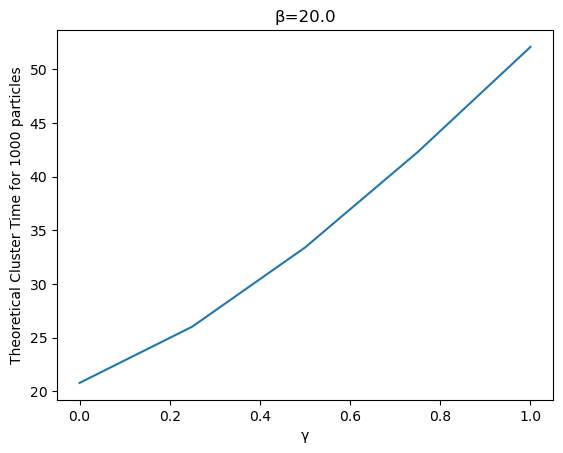

In [19]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
#plt.xscale('log')
#plt.yscale('log')
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

Text(0, 0.5, 'Frequency of phase transition')

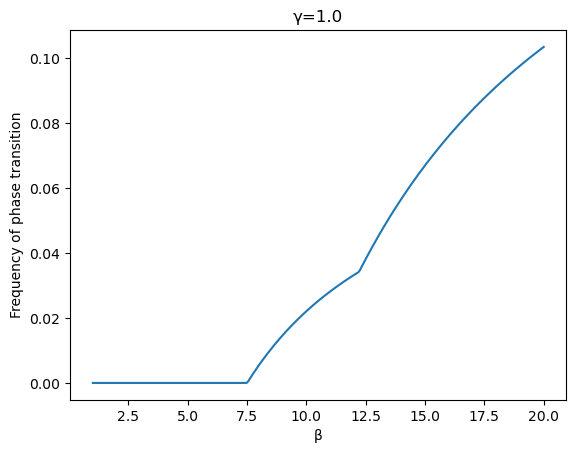

In [20]:
plt.plot(β_list,spectral_radius[:,2])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[-1]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

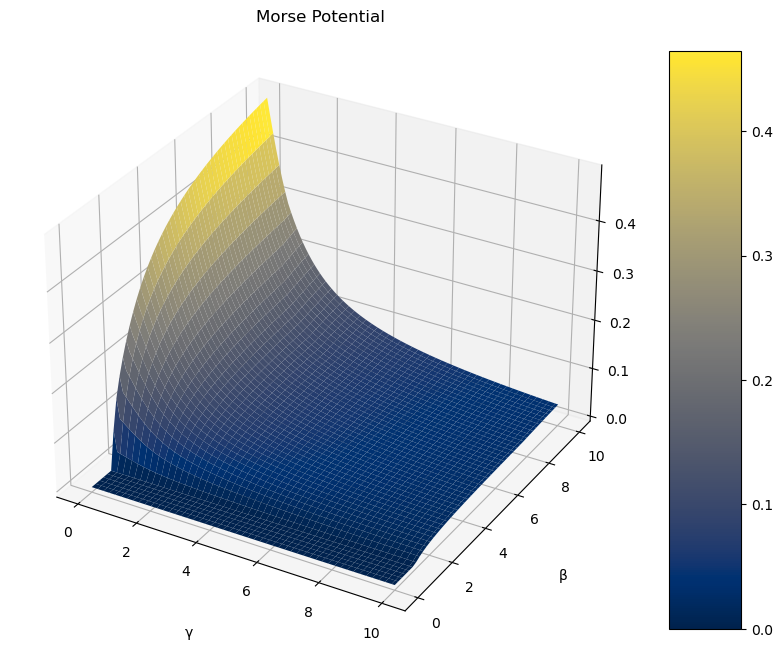

In [50]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Morse Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()